In [56]:
import numpy as np

def dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

In [57]:
def region_query(dataset, index, e):
    neighbors = []

    for i in range(len(dataset)):
        if dist(dataset[index], dataset[i]) <= e:
            neighbors.append(i)

    return neighbors

In [58]:
def dbscan(dataset, e, MinPts):
    n = len(dataset)
    labels = [0] * n   # all points are unvisited
    cluster_id = 0

    for i in range(n):
        if labels[i] != 0:
            continue  # Skipping already visited points

        neighbors = region_query(dataset, i, e) # Finding the neighbours of the point

        if len(neighbors) < MinPts:
            labels[i] = -1  # If there are not enough neighbour points then its a noise
        else:
            cluster_id += 1
            expand_cluster(dataset, labels, i, neighbors, cluster_id, e, MinPts)
            #If its not a noise pt it goes to expand cluster

    return labels

In [59]:
#Function where the cluster grows
def expand_cluster(dataset, labels, index, neighbors, cluster_id, e, MinPts):
    labels[index] = cluster_id #First point becomes a part of the cluster
    #Now we loop over the nighbours
    i = 0
    while i < len(neighbors):
        #Picking a neighbour
        neighbor_index = neighbors[i]

        if labels[neighbor_index] == -1:
            labels[neighbor_index] = cluster_id  # Updating a noise to a border point

        elif labels[neighbor_index] == 0:
            labels[neighbor_index] = cluster_id #Adding an unvisited point to a cluster

            #Getting all the indices of the neigbour points
            neighbor_neighbors = region_query(dataset, neighbor_index, e)

            #If this neighbour also has enough density then we continue the search
            if len(neighbor_neighbors) >= MinPts:
                neighbors += neighbor_neighbors

        i += 1

In [60]:
def classify_points(dataset, labels, e, MinPts):
    n = len(dataset)
    point_type = [""] * n

    # Identifying core points
    core_points = set()

    for i in range(n):
        neighbors = region_query(dataset, i, e)
        if len(neighbors) >= MinPts:
            point_type[i] = "Core"
            core_points.add(i)

    # Identifying border points
    for i in range(n):
        if point_type[i] == "Core":
            continue

        neighbors = region_query(dataset, i, e)

        # Checking if any neighbour is a core to assign border or noise
        if any(n in core_points for n in neighbors):
            point_type[i] = "Border"
        else:
            point_type[i] = "Noise"

    return point_type

In [61]:
import pandas as pd
data = pd.read_csv('/content/Q2_dataset.csv')
data = data.to_numpy()

In [62]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
def plot_dbscan(dataset, labels, point_types, e):
    dataset = np.array(dataset)
    unique_clusters = set(labels)

    plt.figure(figsize=(8, 6))

    for cluster in unique_clusters:
        if cluster == -1:
            color = 'black'  # noise
        else:
            color = plt.cm.tab10(cluster % 10)

        for i in range(len(dataset)):
            if labels[i] == cluster:
                if point_types[i] == "Core":
                    plt.scatter(dataset[i, 0], dataset[i, 1], color = color, marker='o', s=60)
                elif point_types[i] == "Border":
                    plt.scatter(dataset[i, 0], dataset[i, 1], color = color, marker='^', s=40)
                else:
                    plt.scatter(dataset[i, 0], dataset[i, 1], color='black', marker='x', s=40)
    core_legend = mlines.Line2D([], [], color='black', marker='o',linestyle='None', markersize=8, label='Core')

    border_legend = mlines.Line2D([], [], color='black', marker='^',linestyle='None', markersize=8, label='Border')

    noise_legend = mlines.Line2D([], [], color='black', marker='x',linestyle='None', markersize=8, label='Noise')

    plt.legend(handles=[core_legend, border_legend, noise_legend])
    plt.title("DBSCAN Clustering")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

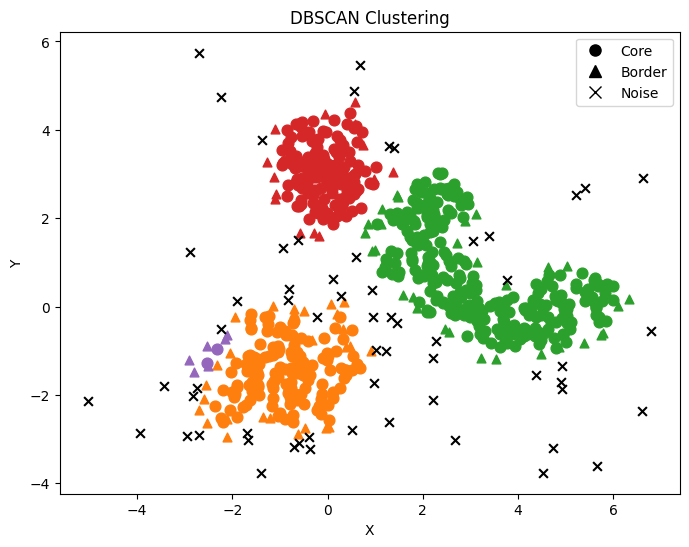

In [63]:
labels = dbscan(data, e=0.4, MinPts=7)
point_types = classify_points(data, labels, e=0.4, MinPts=7)

plot_dbscan(data, labels, point_types, e=0.4)

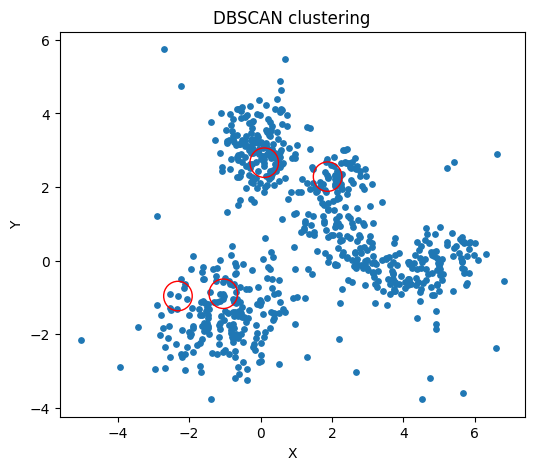

In [64]:
plt.figure(figsize=(6,5))
plt.scatter(data[:,0], data[:,1], s=15)

eps = 0.4
unique_clusters = set(labels)

for cluster in unique_clusters:
    if cluster == -1:
        continue

    for i in range(len(data)):
        if labels[i] == cluster and point_types[i] == "Core":
            x, y = data[i]
            circle = plt.Circle((x, y), eps, color='red', fill=False)
            plt.gca().add_patch(circle)
            break
plt.title("DBSCAN clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [15]:
e_range = np.linspace(0.1, 1.5, 10)
results=[]
for e in e_range:
    labels = dbscan(data, e, MinPts=8)

    labels_set = set(labels)

    # number of clusters (excluding noise)
    num_clusters = len(labels_set - {-1})

    # number of noise points
    num_noise = labels.count(-1)

    # noise ratio
    noise_ratio = num_noise / len(data)

    results.append((e, num_clusters, num_noise, noise_ratio))


In [35]:
print("e\tclusters\tnoise\tnoise_ratio")

for r in results:
    print(f"{r[0]:.2f}\t{r[1]}\t\t{r[2]}\t{r[3]:.3f}")

e	clusters	noise	noise_ratio
0.10	1		692	0.989
0.26	13		316	0.451
0.41	3		73	0.104
0.57	2		24	0.034
0.72	1		18	0.026
0.88	1		14	0.020
1.03	1		12	0.017
1.19	1		12	0.017
1.34	1		11	0.016
1.50	1		7	0.010


In [38]:
e = [r[0] for r in results]
clusters = [r[1] for r in results]
noise_ratio = [r[3] for r in results]
e_3 = None
e_4 = None

for i in range(len(clusters)):
    if clusters[i] == 3 and e_3 is None:
        e_3 = e[i]
    if clusters[i] == 4 and e_4 is None:
        e_4 = e[i]
e_3 = e[np.argmin([abs(c-3) for c in clusters])]
e_4 = e[np.argmin([abs(c-4) for c in clusters])]

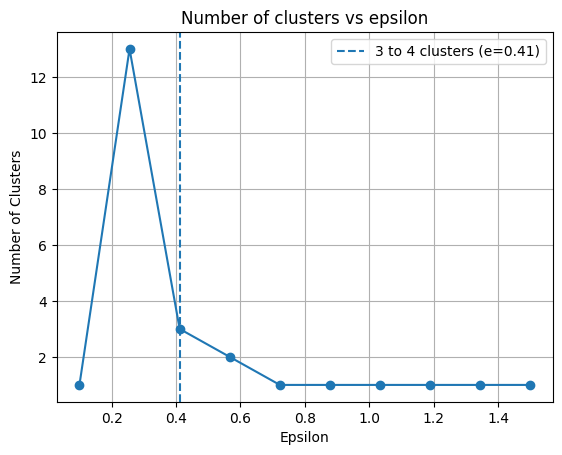

In [40]:
plt.figure()

plt.plot(e, clusters, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Number of Clusters")
plt.title("Number of clusters vs epsilon")

plt.axvline(e_3, linestyle='--', label=f'3 to 4 clusters (e={e_3:.2f})')


plt.legend()
plt.grid()
plt.show()

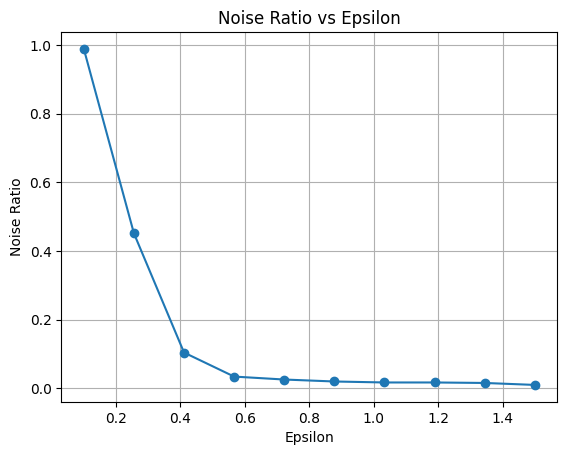

In [26]:
plt.figure()

plt.plot(e, noise_ratio, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Noise Ratio")
plt.title("Noise Ratio vs Epsilon")



plt.grid()
plt.show()

In [30]:
labels_original = dbscan(data, e=0.35, MinPts=8)
types_original = classify_points(data, labels_original, e=0.35, MinPts=8)

np.random.seed(42)
permutation = np.random.permutation(len(data))

shuffled_data = data[permutation]

labels_shuffled = dbscan(shuffled_data, e=0.35, MinPts=8)
types_shuffled = classify_points(shuffled_data, labels_shuffled, e=0.35, MinPts=8)

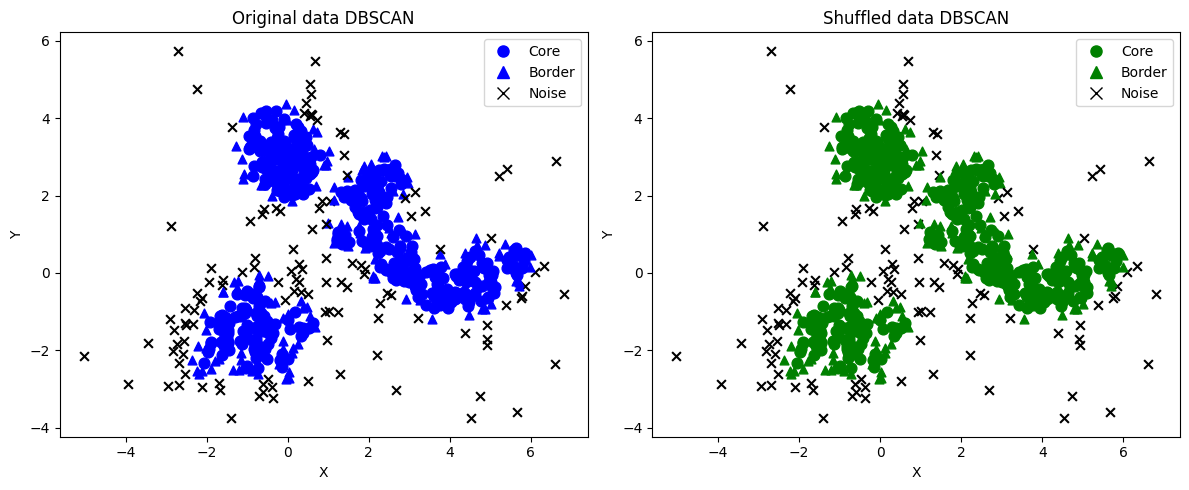

In [47]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)

for i in range(len(data)):
    if labels_original[i] == -1:
        plt.scatter(data[i,0], data[i,1], color='black', marker='x', s=40)
    elif types_original[i] == "Core":
        plt.scatter(data[i,0], data[i,1], color='blue', marker='o', s=60)
    else:
        plt.scatter(data[i,0], data[i,1], color='blue', marker='^', s=40)

core_legend = mlines.Line2D([], [], color='blue', marker='o',linestyle='None', markersize=8, label='Core')

border_legend = mlines.Line2D([], [], color='blue', marker='^',linestyle='None', markersize=8, label='Border')

noise_legend = mlines.Line2D([], [], color='black', marker='x',linestyle='None', markersize=8, label='Noise')

plt.title("Original data DBSCAN")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(handles=[core_legend, border_legend, noise_legend])



plt.subplot(1, 2, 2)

for i in range(len(shuffled_data)):
    if labels_shuffled[i] == -1:
        plt.scatter(shuffled_data[i,0], shuffled_data[i,1], color='black', marker='x', s=40)
    elif types_shuffled[i] == "Core":
        plt.scatter(shuffled_data[i,0], shuffled_data[i,1], color='green', marker='o', s=60)
    else:
        plt.scatter(shuffled_data[i,0], shuffled_data[i,1], color='green', marker='^', s=40)

core_legend1 = mlines.Line2D([], [], color='green', marker='o',linestyle='None', markersize=8, label='Core')

border_legend1 = mlines.Line2D([], [], color='green', marker='^',linestyle='None', markersize=8, label='Border')

noise_legend1 = mlines.Line2D([], [], color='black', marker='x',linestyle='None', markersize=8, label='Noise')
plt.title("Shuffled data DBSCAN")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(handles=[core_legend1, border_legend1, noise_legend1])

plt.tight_layout()
plt.show()

In [51]:
diff = 0

for i in range(len(data)):
    if types_original[i] != types_shuffled[np.where(permutation == i)[0][0]]:
        diff += 1

print("Number of points changes from original to shuffled is ", diff)

Number of points changes from original to shuffled is  0


In [46]:
labels_db = dbscan(data, e=0.4, MinPts=7)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
labels_km = kmeans.fit_predict(data)

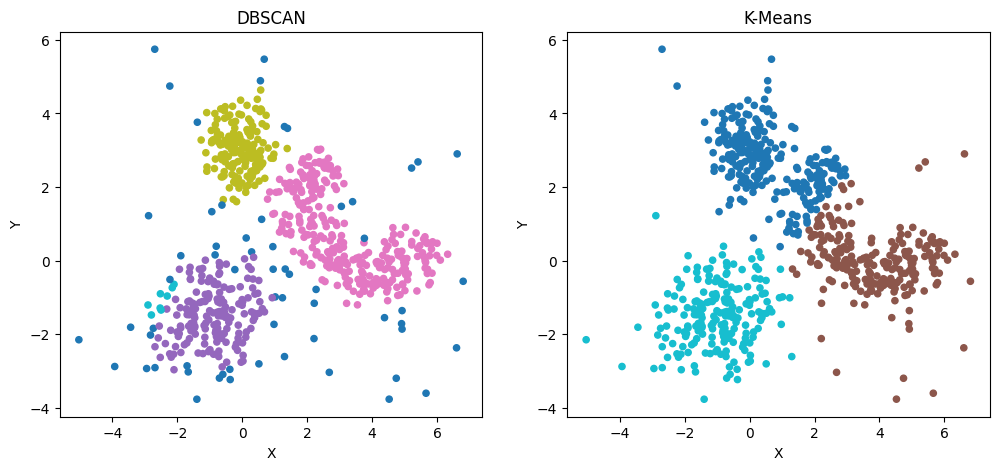

In [50]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(data[:,0], data[:,1], c=labels_db, cmap='tab10', s=20)
plt.title("DBSCAN")
plt.xlabel("X")
plt.ylabel("Y")

plt.subplot(1,2,2)
plt.scatter(data[:,0], data[:,1], c=labels_km, cmap='tab10', s=20)
plt.title("K-Means")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()